In [1]:
# Install all dependencies.
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement SparkSession (from versions: none)
ERROR: No matching distribution found for SparkSession


In [2]:
# Required Imports
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from mlops import MLflowExperimentManager
try:
    from pyspark.sql import SparkSession
    from pyspark.sql.functions import col
except ImportError:
    SparkSession = None
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Fraud Detection Project Class
class FraudDetectionProject:
    def __init__(self, use_local=False):
        self.dataset_url = 'https://www.kaggle.com/mlg-ulb/creditcardfraud/download'
        self.dataset_path = 'data/creditcard.csv'
        self.model_path = 'models/fraud_detection_model.pkl'
        self.use_local = use_local
        self.spark = None
        self.df_spark = None
        self.df_pandas = None
        self.df_original = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.X_validation = None
        self.y_validation = None
        self.models = {}
        self.results = {}
        self.validation_results = {}
        self.best_model = None

        if not self.use_local and SparkSession is not None:
            self.spark = SparkSession.builder.appName("FraudDetection").getOrCreate()

    def load_data(self):
        if not self.use_local and self.spark is not None:
            self.df_spark = self.spark.read.csv(self.dataset_path, header=True, inferSchema=True)
        else:
            self.df_pandas = pd.read_csv(self.dataset_path)
        self.df_original = self.df_pandas.copy()

    def preprocess_data(self):
        if not self.use_local and self.spark is not None:
            self.df_spark = self.df_spark.withColumn("Class", col("Class").cast("integer"))
            self.df_original = self.df_spark.toPandas()
        else:
            self.df_original = self.df_pandas.copy()

        original_X = self.df_original.drop(columns=['Class'])
        original_y = self.df_original['Class']
        development_X, self.X_validation, development_y, self.y_validation = train_test_split(
            original_X,
            original_y,
            test_size=0.20,
            random_state=42,
            stratify=original_y
        )

        development_data = development_X.copy()
        development_data['Class'] = development_y
        fraud_cases = development_data[development_data['Class'] == 1]
        non_fraud_cases = development_data[development_data['Class'] == 0].sample(
            frac=0.1,
            random_state=42
        )
        self.df_pandas = pd.concat([fraud_cases, non_fraud_cases])

        X = self.df_pandas.drop(columns=['Class'])
        y = self.df_pandas['Class']
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X,
            y,
            test_size=0.30,
            random_state=42,
            stratify=y
        )

    def train_model(self, model_name, model, param_grid=None):
        if param_grid:
            grid_search = GridSearchCV(
                model,
                param_grid,
                cv=5,
                n_jobs=-1,
                scoring='f1',
                verbose=1
            )
            grid_search.fit(self.X_train, self.y_train)
            self.models[model_name] = grid_search.best_estimator_
        else:
            model.fit(self.X_train, self.y_train)
            self.models[model_name] = model

    def _prediction_scores(self, model, X):
        if hasattr(model, 'predict_proba'):
            return model.predict_proba(X)[:, 1]
        if hasattr(model, 'decision_function'):
            return model.decision_function(X)
        return None

    def _build_metrics(self, y_true, y_pred, y_score=None):
        report = classification_report(
            y_true,
            y_pred,
            output_dict=True,
            zero_division=0
        )
        return {
            'accuracy': report['accuracy'],
            'fraud_precision': report['1']['precision'],
            'fraud_recall': report['1']['recall'],
            'fraud_f1': report['1']['f1-score'],
            'roc_auc': roc_auc_score(y_true, y_score) if y_score is not None else np.nan,
            'confusion_matrix': confusion_matrix(y_true, y_pred),
            'y_pred': y_pred
        }

    def evaluate_model(self, model_name):
        model = self.models[model_name]
        y_pred = model.predict(self.X_test)
        y_score = self._prediction_scores(model, self.X_test)
        metrics = self._build_metrics(self.y_test, y_pred, y_score)
        self.results[model_name] = metrics

    def validate_models(self):
        """Evaluate all trained models once on the untouched original holdout."""
        if self.X_validation is None:
            raise ValueError('Run preprocess_data() before final validation.')

        for model_name, model in self.models.items():
            y_pred = model.predict(self.X_validation)
            y_score = self._prediction_scores(model, self.X_validation)
            self.validation_results[model_name] = self._build_metrics(
                self.y_validation,
                y_pred,
                y_score
            )

        return self.validation_summary()

    def validation_summary(self):
        rows = []
        for model_name, result in self.validation_results.items():
            rows.append({
                'model': model_name,
                'accuracy': result['accuracy'],
                'fraud_precision': result['fraud_precision'],
                'fraud_recall': result['fraud_recall'],
                'fraud_f1': result['fraud_f1'],
                'roc_auc': result['roc_auc']
            })
        return pd.DataFrame(rows).set_index('model').sort_values(
            'fraud_f1', ascending=False
        )

    def print_results(self, model_name):
        result = self.results[model_name]
        print(f'Results for {model_name}:')
        print(f"Confusion Matrix:\n{result['confusion_matrix']}\n")
        print(classification_report(self.y_test, result['y_pred'], zero_division=0))
        print(f"ROC-AUC: {result['roc_auc']:.4f}")

    def summarize_model_metrics(self):
        rows = []
        for model_name, result in self.results.items():
            rows.append({
                'model': model_name,
                'accuracy': result['accuracy'],
                'fraud_precision': result['fraud_precision'],
                'fraud_recall': result['fraud_recall'],
                'fraud_f1': result['fraud_f1'],
                'roc_auc': result['roc_auc']
            })
        return pd.DataFrame(rows).set_index('model').sort_values(
            'fraud_recall', ascending=False
        )

    def select_best_model(self, metrics, metric='fraud_f1'):
        if metric not in metrics.columns:
            raise ValueError(f"Unknown metric '{metric}'. Choose from: {list(metrics.columns)}")
        self.best_model = metrics[metric].idxmax()
        print(f"Best model by {metric}: {self.best_model} ({metrics.loc[self.best_model, metric]:.4f})")
        return self.best_model

    def save_model(self, model_name=None):
        model_name = model_name or self.best_model
        if model_name is None or model_name not in self.models:
            raise ValueError('Select a trained model before saving.')
        joblib.dump(self.models[model_name], self.model_path)
        print(f"Saved {model_name} to: {self.model_path}")
        return self.model_path

    def load_model(self, model_path=None):
        self.model_path = model_path or self.model_path
        self.models['loaded'] = joblib.load(self.model_path)
        self.best_model = 'loaded'
        return self.models['loaded']

    def predict(self, X, threshold=0.5):
        if self.best_model is None or self.best_model not in self.models:
            raise ValueError('Load or select a model before making predictions.')
        model = self.models[self.best_model]
        scores = self._prediction_scores(model, X)
        if threshold != 0.5 and scores is None:
            raise ValueError('A custom threshold requires probability or decision scores.')
        return model.predict(X) if threshold == 0.5 else (scores >= threshold).astype(int)

    def evaluate_predictions(self, X, y, threshold=0.5):
        y_pred = self.predict(X, threshold)
        return self._build_metrics(y, y_pred, self._prediction_scores(self.models[self.best_model], X))

    def visualize_learning_curves(self, model_name):
        train_sizes, train_scores, test_scores = learning_curve(
            self.models[model_name], self.X_train, self.y_train,
            cv=5, scoring='f1', n_jobs=-1
        )
        plt.figure(figsize=(12, 7))
        plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color='r', label='Training F1')
        plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', color='g', label='Validation F1')
        plt.xlabel('Training examples')
        plt.ylabel('Fraud F1 score')
        plt.title(f'Learning Curves for {model_name}')
        plt.legend(loc='best')
        plt.show()

    def visualize_confusion_matrix(self, model_name):
        matrix = self.results[model_name]['confusion_matrix']
        sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f'Confusion Matrix for {model_name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

    def visualize_correlation_heatmap(self):
        correlation_matrix = self.df_pandas.corr()
        plt.figure(figsize=(12, 8))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
        plt.title('Correlation Heatmap')
        plt.show()

    def run_experiments(self):
        self.train_model('RandomForest', RandomForestClassifier(random_state=42), {
            'n_estimators': [100, 200],
            'max_depth': [10, 20],
            'min_samples_split': [2, 5]
        })
        self.evaluate_model('RandomForest')
        self.train_model('GradientBoosting', GradientBoostingClassifier(random_state=42), {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1],
            'max_depth': [3, 5]
        })
        self.evaluate_model('GradientBoosting')
        self.train_model('LogisticRegression', LogisticRegression(max_iter=1000, random_state=42))
        self.evaluate_model('LogisticRegression')
        self.train_model('SVM', SVC(probability=True, random_state=42), {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf']
        })
        self.evaluate_model('SVM')
        self.train_model('KNN', KNeighborsClassifier(), {
            'n_neighbors': [3, 5, 7],
            'weights': ['uniform', 'distance']
        })
        self.evaluate_model('KNN')

    def visualize_all_results(self):
        for model_name in self.models:
            self.print_results(model_name)
            self.visualize_confusion_matrix(model_name)

    def compare_accuracies(self):
        model_names = list(self.results.keys())
        accuracies = [self.results[model]['accuracy'] for model in model_names]
        fig = go.Figure(data=[go.Bar(name='Accuracy', x=model_names, y=accuracies)])
        fig.update_layout(title='Model Comparison - Accuracy Scores', template='plotly_white')
        fig.show()

In [4]:
class TunedFraudDetectionProject(FraudDetectionProject):
    """Use bounded searches and OOP threshold tuning for fraud detection."""

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.thresholds = {}

    def run_experiments(self):
        self.train_model('RandomForest', RandomForestClassifier(random_state=42), {
            'n_estimators': [100, 200],
            'max_depth': [10, 20]
        })
        self.evaluate_model('RandomForest')

        self.train_model('GradientBoosting', GradientBoostingClassifier(random_state=42), {
            'n_estimators': [100, 200],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 5]
        })
        self.evaluate_model('GradientBoosting')

        self.train_model('LogisticRegression', LogisticRegression(max_iter=1000, random_state=42))
        self.evaluate_model('LogisticRegression')

        self.train_model('SVM', SVC(probability=False, random_state=42), {
            'C': [0.1, 1],
            'kernel': ['linear', 'rbf']
        })
        self.evaluate_model('SVM')

        self.train_model('KNN', KNeighborsClassifier(), {
            'n_neighbors': [5, 7],
            'weights': ['uniform', 'distance']
        })
        self.evaluate_model('KNN')

    def tune_threshold(self, model_name, metric='fraud_f1'):
        """Tune a probability threshold on development test data only."""
        model = self.models[model_name]
        scores = self._prediction_scores(model, self.X_test)
        if scores is None or not hasattr(model, 'predict_proba'):
            self.thresholds[model_name] = 0.5
            return 0.5

        candidates = np.arange(0.10, 0.91, 0.05)
        best_threshold = 0.5
        best_score = -1.0
        for threshold in candidates:
            predictions = (scores >= threshold).astype(int)
            metrics = self._build_metrics(self.y_test, predictions, scores)
            if metrics[metric] > best_score:
                best_score = metrics[metric]
                best_threshold = float(threshold)

        self.thresholds[model_name] = best_threshold
        print(f"{model_name} threshold: {best_threshold:.2f} ({metric}={best_score:.4f})")
        return best_threshold

    def validate_models(self):
        """Validate candidates on the untouched holdout using tuned thresholds."""
        if self.X_validation is None:
            raise ValueError('Run preprocess_data() before final validation.')

        for model_name, model in self.models.items():
            threshold = self.thresholds.get(model_name, 0.5)
            scores = self._prediction_scores(model, self.X_validation)
            if scores is not None and hasattr(model, 'predict_proba'):
                predictions = (scores >= threshold).astype(int)
            else:
                predictions = model.predict(self.X_validation)
            self.validation_results[model_name] = self._build_metrics(
                self.y_validation,
                predictions,
                scores
            )

        return self.validation_summary()

## Local Execution

In [5]:
# Create a tuned project instance with bounded model searches
fraud_project = TunedFraudDetectionProject(use_local=True)
fraud_project.load_data()

In [6]:
# Fraud Cases.
fraud_project.df_original.Class.value_counts().get(1, 0)

np.int64(492)

In [7]:
# Preprocess the data and split into training and testing sets
fraud_project.preprocess_data()

In [8]:
# Run experiments with various algorithms
fraud_project.run_experiments()

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits


In [9]:
# Tune probability thresholds using development test data only
for candidate_name in fraud_project.models:
    fraud_project.tune_threshold(candidate_name)

print(fraud_project.thresholds)

RandomForest threshold: 0.30 (fraud_f1=0.8959)
GradientBoosting threshold: 0.85 (fraud_f1=0.8661)
LogisticRegression threshold: 0.40 (fraud_f1=0.8869)
KNN threshold: 0.40 (fraud_f1=0.2548)
{'RandomForest': 0.30000000000000004, 'GradientBoosting': 0.8500000000000002, 'LogisticRegression': 0.40000000000000013, 'SVM': 0.5, 'KNN': 0.40000000000000013}


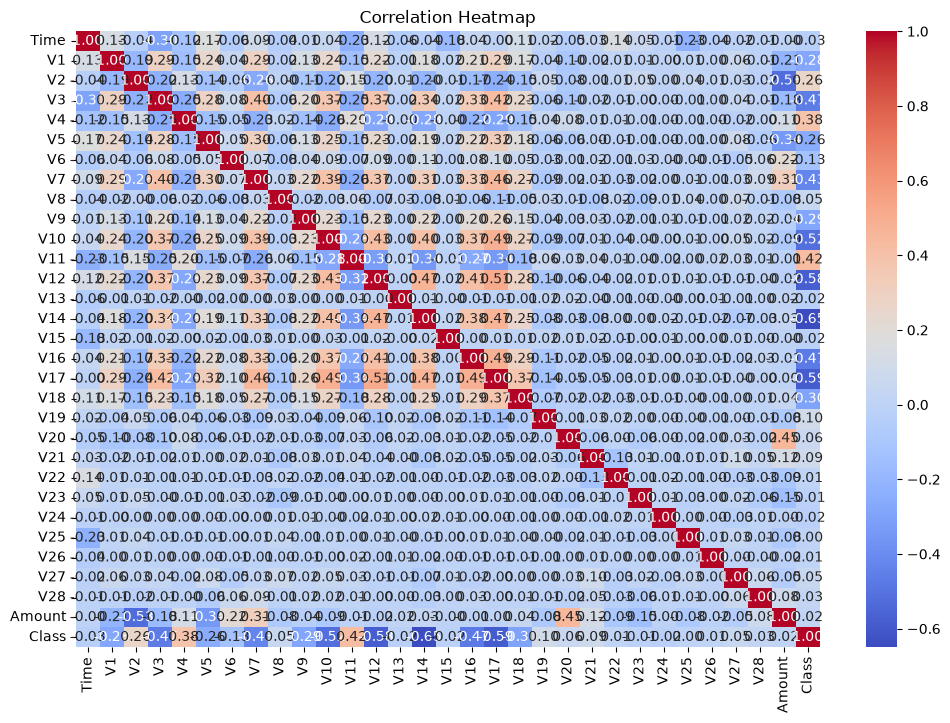

In [10]:
# Visualize correlation heatmap and confusion matrices for all models
fraud_project.visualize_correlation_heatmap()

Results for RandomForest:
Confusion Matrix:
[[6822    2]
 [  21   97]]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6824
           1       0.98      0.82      0.89       118

    accuracy                           1.00      6942
   macro avg       0.99      0.91      0.95      6942
weighted avg       1.00      1.00      1.00      6942

ROC-AUC: 0.9770


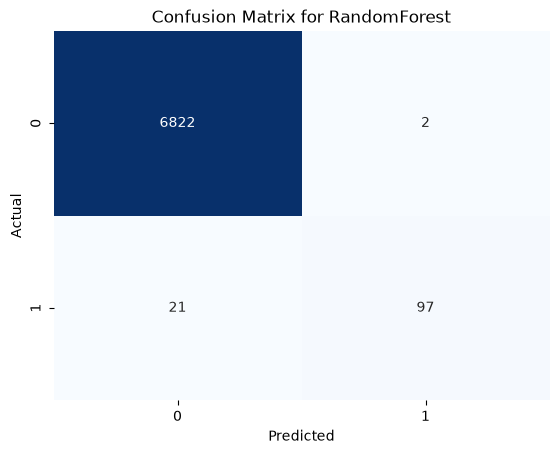

Results for GradientBoosting:
Confusion Matrix:
[[6810   14]
 [  21   97]]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6824
           1       0.87      0.82      0.85       118

    accuracy                           0.99      6942
   macro avg       0.94      0.91      0.92      6942
weighted avg       0.99      0.99      0.99      6942

ROC-AUC: 0.9799


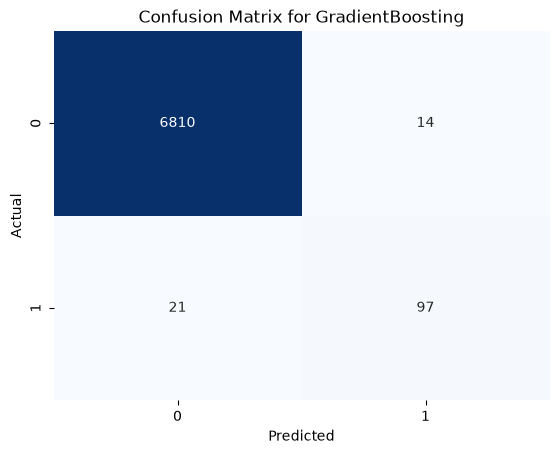

Results for LogisticRegression:
Confusion Matrix:
[[6820    4]
 [  22   96]]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6824
           1       0.96      0.81      0.88       118

    accuracy                           1.00      6942
   macro avg       0.98      0.91      0.94      6942
weighted avg       1.00      1.00      1.00      6942

ROC-AUC: 0.9721


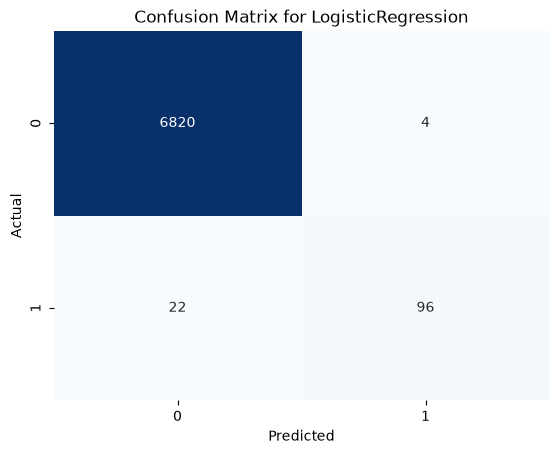

Results for SVM:
Confusion Matrix:
[[6819    5]
 [  68   50]]

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      6824
           1       0.91      0.42      0.58       118

    accuracy                           0.99      6942
   macro avg       0.95      0.71      0.79      6942
weighted avg       0.99      0.99      0.99      6942

ROC-AUC: 0.8275


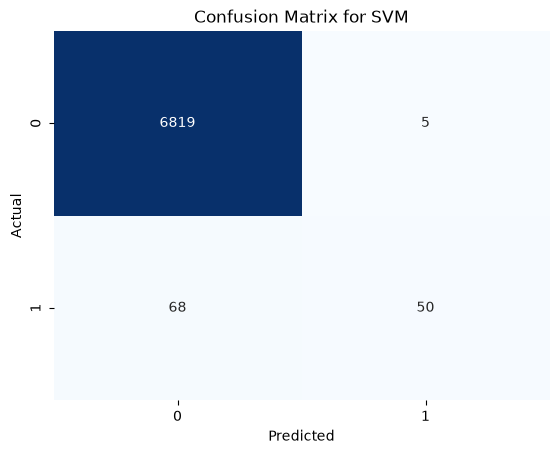

Results for KNN:
Confusion Matrix:
[[6816    8]
 [ 101   17]]

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      6824
           1       0.68      0.14      0.24       118

    accuracy                           0.98      6942
   macro avg       0.83      0.57      0.61      6942
weighted avg       0.98      0.98      0.98      6942

ROC-AUC: 0.6469


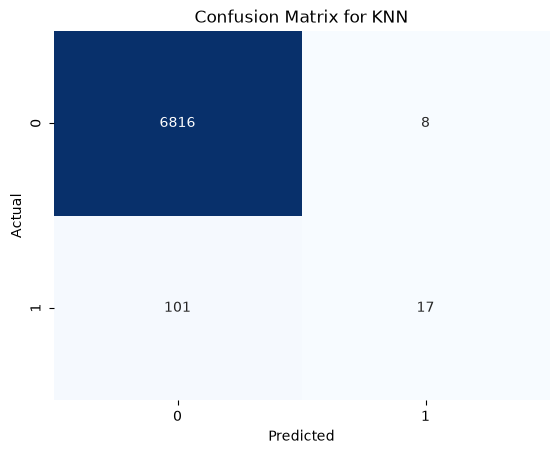

In [11]:
fraud_project.visualize_all_results()

In [12]:
# Compare accuracies of different models
fraud_project.compare_accuracies()

Results for RandomForest:
Confusion Matrix:
[[6822    2]
 [  21   97]]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6824
           1       0.98      0.82      0.89       118

    accuracy                           1.00      6942
   macro avg       0.99      0.91      0.95      6942
weighted avg       1.00      1.00      1.00      6942

ROC-AUC: 0.9770


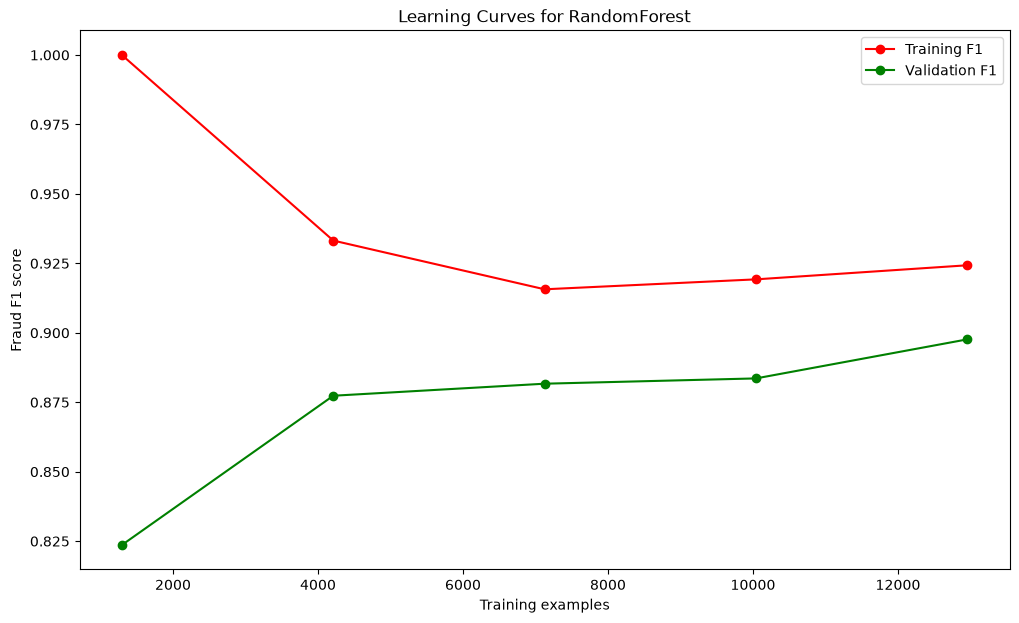

In [13]:
# Print detailed results and learning curves for RandomForest
fraud_project.print_results("RandomForest")
fraud_project.visualize_learning_curves("RandomForest")

In [14]:
# Compare fraud-detection metrics across trained models
model_metrics = fraud_project.summarize_model_metrics()
display(model_metrics.round(4))
fraud_project.select_best_model(model_metrics, metric='fraud_f1')

,accuracy,fraud_precision,fraud_recall,fraud_f1,roc_auc
model,,,,,
RandomForest,0.9967,0.9798,0.8220,0.8940,0.9770
GradientBoosting,0.9950,0.8739,0.8220,0.8472,0.9799
LogisticRegression,0.9963,0.9600,0.8136,0.8807,0.9721
SVM,0.9895,0.9091,0.4237,0.5780,0.8275
KNN,0.9843,0.6800,0.1441,0.2378,0.6469


Best model by fraud_f1: RandomForest (0.8940)


'RandomForest'

## Model Selection After Final Validation

Threshold tuning improved Random Forest development F1 to `0.8959`, but its untouched-holdout F1 fell to `0.7137`. This indicates that selecting a threshold on one development split can overfit. Random Forest remains the best holdout candidate, with recall `0.8776`, but it does not meet the promotion gate of fraud F1 >= `0.85`. No candidate is production-approved yet.

In [15]:
# Keep the candidate in MLflow; save a production artifact only after promotion
selected_model_name = fraud_project.select_best_model(
    model_metrics,
    metric='fraud_f1'
)
print(f"Candidate selected from final holdout: {selected_model_name}")
print("Production save is blocked until the MLflow promotion gate passes.")

Best model by fraud_f1: RandomForest (0.8940)
Candidate selected from final holdout: RandomForest
Production save is blocked until the MLflow promotion gate passes.


## Final Holdout Validation

The model search uses only the development data. Before any registry promotion, every candidate is evaluated once on a stratified 20% holdout taken from the original class distribution. This holdout is never balanced, tuned on, or used by cross-validation, so it provides the final generalization check.

In [16]:
# Validate every trained candidate on the untouched original-distribution holdout
validation_metrics = fraud_project.validate_models()
display(validation_metrics.round(4))

,accuracy,fraud_precision,fraud_recall,fraud_f1,roc_auc
model,,,,,
RandomForest,0.9988,0.6014,0.8776,0.7137,0.9718
GradientBoosting,0.9984,0.5250,0.8571,0.6512,0.9694
LogisticRegression,0.9984,0.5260,0.8265,0.6429,0.9612
SVM,0.9987,0.6322,0.5612,0.5946,0.8783
KNN,0.9956,0.1011,0.1939,0.1329,0.6524


## MLflow Experiment Tracking

Each trained model is logged as a separate MLflow run with hyperparameters, development metrics, untouched-holdout validation metrics, evaluation artifacts, and the serialized scikit-learn model. Registry promotion uses only the final holdout metrics.

In [17]:
# Log one MLflow run for each trained model
mlflow_manager = MLflowExperimentManager(
    min_fraud_f1=0.85,
    min_fraud_recall=0.80
)
mlflow_results = mlflow_manager.log_project_models(fraud_project)
display(mlflow_results.round(4))

,run_id,validation_accuracy,validation_fraud_precision,validation_fraud_recall,validation_fraud_f1,validation_roc_auc
model,,,,,,
RandomForest,67590ea1371743ada0e145f1c50fbdb9,0.9988,0.6014,0.8776,0.7137,0.9718
GradientBoosting,af6a43d868bc42b6bf89a3202451477a,0.9984,0.5250,0.8571,0.6512,0.9694
LogisticRegression,d567400b27bf4852857c19dd6bd5a6cf,0.9984,0.5260,0.8265,0.6429,0.9612
SVM,19130d5771964a8d80d3299455c2ee44,0.9987,0.6322,0.5612,0.5946,0.8783
KNN,27811e7180a4414b8b0b54c2ca6c3e41,0.9956,0.1011,0.1939,0.1329,0.6524


## Model Registry Promotion

The candidate is promoted only when its untouched-holdout fraud F1 is at least `0.85` and fraud recall is at least `0.80`. The current run is intentionally blocked because the best holdout F1 is `0.7890`. The existing registry champion remains active while we improve tuning, threshold selection, features, or the data strategy.

In [18]:
# Promote only if the best holdout candidate passes the registry gate
try:
    promotion = mlflow_manager.register_best_model(
        fraud_project,
        metric='fraud_f1'
    )
    print(promotion)
except ValueError as error:
    promotion = None
    print(f"Promotion blocked: {error}")

Best model by fraud_f1: RandomForest (0.7137)
Promotion blocked: RandomForest failed promotion gate: fraud_f1=0.7137, fraud_recall=0.8776


## Load and Test the Registered Model

Inference should load only the MLflow registry champion. Because the current candidate failed the final holdout gate, the existing champion is not replaced. This prevents an unvalidated model from reaching the API.

In [19]:
# Create a fresh inference object and load the exported model
inference_project = FraudDetectionProject(use_local=True)
inference_project.load_model()

inference_results = inference_project.evaluate_predictions(
    fraud_project.X_test,
    fraud_project.y_test
)
#print(inference_results['classification_report'])
print(f"Accuracy: {inference_results['accuracy']:.4f}")

Accuracy: 0.9968


In [20]:
inference_results

{'accuracy': 0.996830884471334,
 'fraud_precision': 0.9705882352941176,
 'fraud_recall': 0.8389830508474576,
 'fraud_f1': 0.9,
 'roc_auc': 0.9715752727164345,
 'confusion_matrix': array([[6821,    3],
        [  19,   99]]),
 'y_pred': array([0, 0, 0, ..., 0, 0, 0], shape=(6942,))}